In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
mnist=fetch_openml("mnist_784", version=1, as_frame=False)

In [3]:
mnist.data.shape

(70000, 784)

In [4]:
type(mnist)

sklearn.utils._bunch.Bunch

In [5]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [6]:
x=mnist.data
y=mnist.target

In [7]:
print(x.shape)
print(y.shape)

(70000, 784)
(70000,)


In [8]:
print(type(x), type(y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [9]:
x[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [10]:
y[0]

'5'

In [11]:
y[:10]

array(['5', '0', '4', '1', '9', '2', '1', '3', '1', '4'], dtype=object)

In [12]:
unique, counts=np.unique(y, return_counts=True)

In [13]:
print(unique, counts)

['0' '1' '2' '3' '4' '5' '6' '7' '8' '9'] [6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]


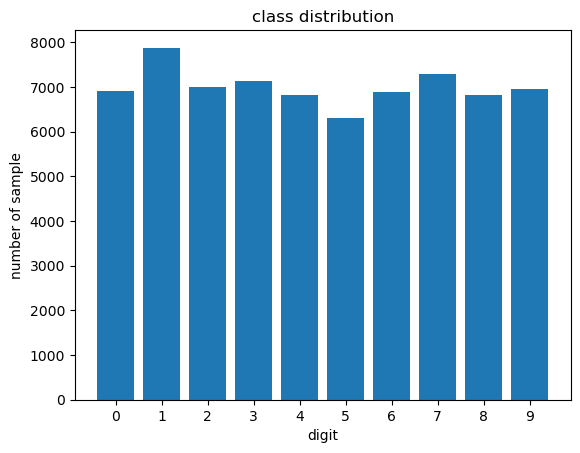

In [14]:
plt.bar(unique, counts)
plt.xlabel("digit")
plt.ylabel("number of sample")
plt.title("class distribution")
plt.show()

In [15]:
sum(counts)

np.int64(70000)

In [16]:
image=x[0].reshape(28, 28)

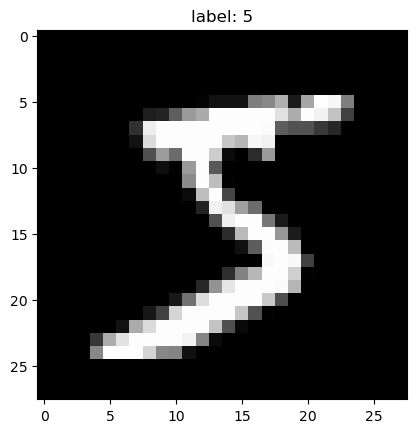

In [17]:
plt.imshow(image, cmap="gray")
plt.title(f"label: {y[0]}")
plt.show()

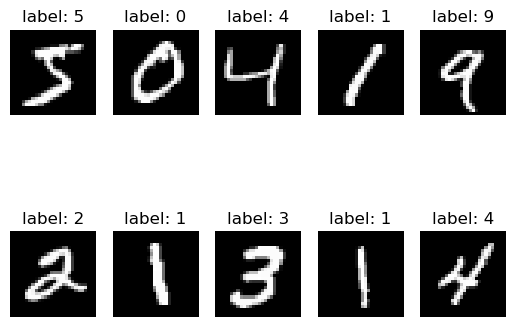

In [18]:
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x[i].reshape(28, 28), cmap="gray")
    plt.title(f"label: {y[i]}")
    plt.axis("off")
    
plt.show()

overview:
- dataset contains 70,000 handwritten digit images
- each image has 784 features(28 x 28 pixels)
- pixel value range is from 0 to 255
- number of classes are 10, classes are from 0 to 9
- the distribution of data is relativly balanced
- each sample contains an image that represents its label


In [19]:
mean_0=x[y=="0"].mean(axis=0)

In [20]:
mean_0.shape

(784,)

In [21]:
mean_image_0=mean_0.reshape(28, 28)

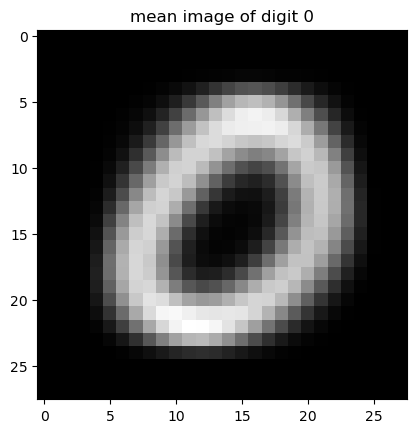

In [22]:
plt.imshow(mean_image_0, cmap="gray")
plt.title("mean image of digit 0")
plt.show()

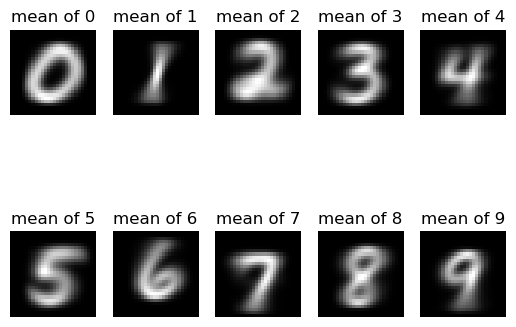

In [23]:
for digit in unique:
    plt.subplot(2, 5, int(digit)+1)
    images=x[y==digit]
    mean_image=images.mean(axis=0).reshape(28, 28)
    plt.imshow(mean_image, cmap="gray")
    plt.title(f"mean of {digit}")
    plt.axis("off")

plt.show()

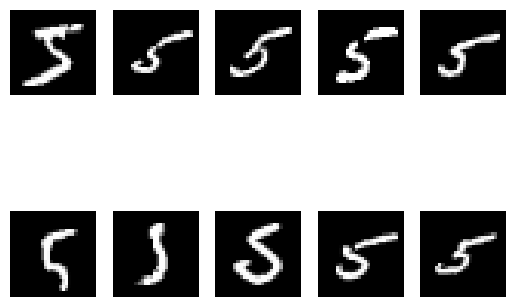

In [24]:
images=x[y=="5"]

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

EDA overview:
- mean image of all digits are recognizable
- examined different samples of the digit to understand handwriting variation

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y)

In [27]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(56000, 784)
(14000, 784)
(56000,)
(14000,)


In [28]:
y_test_unique, y_test_count=np.unique(y_train, return_counts=True)

In [29]:
print(y_test_unique, y_test_count)

['0' '1' '2' '3' '4' '5' '6' '7' '8' '9'] [5522 6302 5592 5713 5459 5050 5501 5834 5460 5567]


In [30]:
x_train=x_train/255
x_test=x_test/255

In [31]:
print(x_train.min())
print(x_train.max())

0.0
1.0


In [32]:
x_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

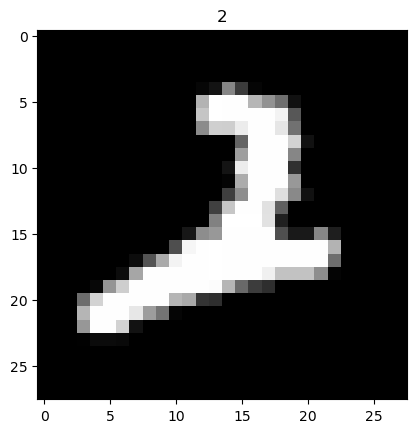

In [33]:
im=x_train[0].reshape(28, 28)
plt.imshow(im, cmap="gray")
plt.title(y_train[0])
plt.show()

data preprocessing overview:
- split the dataset into train and test sets using an 80/20 ratio
- normalized pixel values from the range 0-255 to 0-1
- verified that the normalized images still preserve their

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
LR_model=LogisticRegression(max_iter=1000)

In [36]:
LR_model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [37]:
y_pred_LR=LR_model.predict(x_test)

In [38]:
print(f"actual digits: {y_test[0:9]}")
print(f"predicted digits: {y_pred_LR[0:9]}")

actual digits: ['5' '1' '9' '3' '4' '7' '6' '6' '4']
predicted digits: ['5' '1' '9' '3' '8' '7' '6' '6' '4']


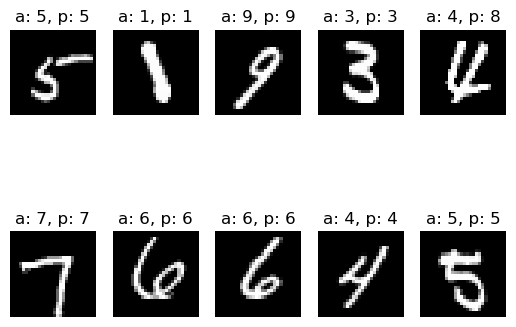

In [39]:
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"a: {y_test[i]}, p: {y_pred_LR[i]}")
    plt.axis("off")
    
plt.show()

In [40]:
from sklearn.metrics import accuracy_score

In [41]:
accuracy_score(y_test, y_pred_LR)

0.9229285714285714

In [42]:
from sklearn.metrics import classification_report

In [43]:
LR_report=classification_report(y_test, y_pred_LR, output_dict=True)

In [44]:
pd.DataFrame(LR_report)

,0,1,2,3,4,5,6,7,8,9,accuracy,macro avg,weighted avg
precision,0.959169,0.948020,0.922280,0.892042,0.945846,0.893927,0.948645,0.930518,0.880178,0.901226,0.922929,0.922185,0.922721
recall,0.969587,0.972698,0.891273,0.902661,0.934066,0.874109,0.967273,0.936258,0.871795,0.898634,0.922929,0.921835,0.922929
f1-score,0.964350,0.960201,0.906511,0.897320,0.939919,0.883907,0.957868,0.933379,0.875966,0.899928,0.922929,0.921935,0.922749
support,1381.000000,1575.000000,1398.000000,1428.000000,1365.000000,1263.000000,1375.000000,1459.000000,1365.000000,1391.000000,0.922929,14000.000000,14000.000000


In [45]:
from sklearn.metrics import confusion_matrix

In [46]:
confusion_matrix(y_test, y_pred_LR)

array([[1339,    0,    4,    3,    3,   12,    9,    3,    6,    2],
       [   1, 1532,   10,    4,    0,    5,    1,    4,   18,    0],
       [   4,   21, 1246,   33,    8,    2,   22,   11,   47,    4],
       [   4,    9,   29, 1289,    2,   42,    2,   15,   24,   12],
       [   4,    4,    6,    3, 1275,    1,    8,    7,   10,   47],
       [  14,   10,   11,   43,    7, 1104,   21,    7,   33,   13],
       [   8,    3,    6,    0,    5,   16, 1330,    1,    5,    1],
       [   9,    3,   12,    8,   13,    4,    0, 1366,    6,   38],
       [   7,   27,   23,   39,    6,   41,    9,    3, 1190,   20],
       [   6,    7,    4,   23,   29,    8,    0,   51,   13, 1250]])

training baseline model overall:
- trained a logistic regression model as baseline for digit classification
- the model achieved an accuracy of 91.97% on test set
- the classification report showed good performance overall
- the confusion matrics showed that the model confused 3&5, 4&9 and 7&9

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
RF_model=RandomForestClassifier()

In [49]:
RF_model.fit(x_train, y_train)

RandomForestClassifier()

In [50]:
y_pred_RF=RF_model.predict(x_test)

In [51]:
accuracy_score(y_test, y_pred_RF)

0.9697142857142858

In [52]:
RF_report=classification_report(y_test, y_pred_RF, output_dict=True)

In [53]:
pd.DataFrame(RF_report)

,0,1,2,3,4,5,6,7,8,9,accuracy,macro avg,weighted avg
precision,0.975018,0.981646,0.961702,0.959212,0.972344,0.979741,0.974874,0.973847,0.963045,0.955072,0.969714,0.969650,0.969702
recall,0.989138,0.984762,0.969957,0.955182,0.978755,0.957245,0.987636,0.969842,0.954579,0.947520,0.969714,0.969462,0.969714
f1-score,0.982027,0.983201,0.965812,0.957193,0.975539,0.968362,0.981214,0.971841,0.958793,0.951281,0.969714,0.969526,0.969680
support,1381.000000,1575.000000,1398.000000,1428.000000,1365.000000,1263.000000,1375.000000,1459.000000,1365.000000,1391.000000,0.969714,14000.000000,14000.000000


In [54]:
confusion_matrix(y_test, y_pred_RF)

array([[1366,    1,    1,    1,    0,    2,    4,    0,    5,    1],
       [   1, 1551,   13,    2,    0,    0,    1,    4,    3,    0],
       [   3,    4, 1356,   11,    0,    1,    7,    8,    8,    0],
       [   2,    1,   15, 1364,    1,   11,    2,   12,   11,    9],
       [   3,    1,    0,    1, 1336,    0,    5,    1,    3,   15],
       [   7,    2,    0,   15,    4, 1209,    9,    1,    9,    7],
       [   5,    3,    0,    0,    1,    6, 1358,    0,    2,    0],
       [   4,    4,   10,    2,    7,    0,    0, 1415,    2,   15],
       [   4,    9,    9,    6,    8,    4,    6,    1, 1303,   15],
       [   6,    4,    6,   20,   17,    1,    1,   11,    7, 1318]])

training 2end model(random forest) overveiw:
- a random forest classifier was trained for handwritten digit classification
- the model achieved 97.06% accuracy on test set
- the classification report showed high precision, recall and f1_scores for all digits
- the confusion matrix showed that most predictions were correct
- the previous confusion between 3 & 5, 7 & 9 and 4 & 9 was significantlt reduced compared to logistic regression model
- random forest preformed better then logistic regression baseline

In [55]:
wrong_pred=np.where(y_test!=y_pred_RF)[0]

In [56]:
len(wrong_pred)

424

In [57]:
idx=wrong_pred[405]

In [58]:
print(f"actual digit={y_test[idx]}")
print(f"predicted digit={y_pred_RF[idx]}")

actual digit=9
predicted digit=3


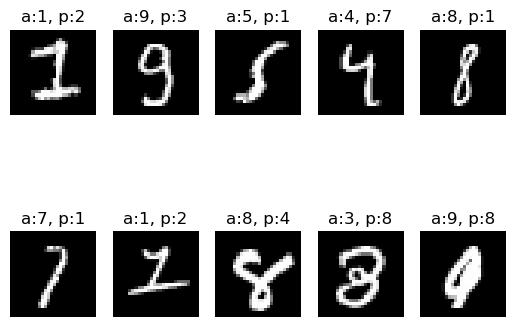

In [59]:
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[wrong_pred[i]].reshape(28, 28), cmap="gray")
    plt.title(f"a:{y_test[wrong_pred[i]]}, p:{y_pred_RF[wrong_pred[i]]}")
    plt.axis("off")
plt.show()

we can see some wrong predictions that the random forest model made

In [60]:
from PIL import Image

In [88]:
my_image=Image.open(r"C:\Users\USER\Pictures\Screenshots\Screenshot 2026-10-08 183008.png")

In [89]:
my_image.size

(240, 239)

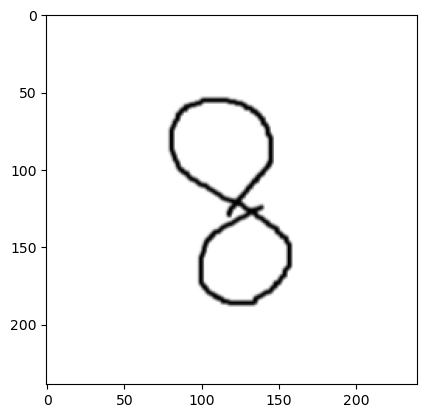

In [90]:
plt.imshow(my_image)
plt.show()

In [91]:
my_image.mode

'RGBA'

In [92]:
my_image=my_image.convert(mode="L")

In [93]:
my_image.mode

'L'

In [94]:
my_image=my_image.resize([28, 28])

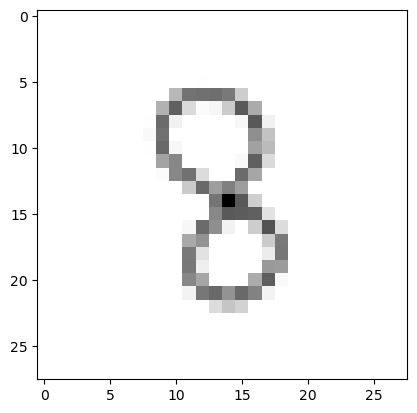

In [95]:
plt.imshow(my_image, cmap="gray")
plt.show()

In [96]:
my_image=np.array(my_image)

In [97]:
my_image.shape

(28, 28)

In [98]:
print(f"max: {my_image.max()}")
print(f"min: {my_image.min()}")

max: 255
min: 98


In [99]:
my_image=255-my_image

In [100]:
print(f"max: {my_image.max()}")
print(f"min: {my_image.min()}")

max: 157
min: 0


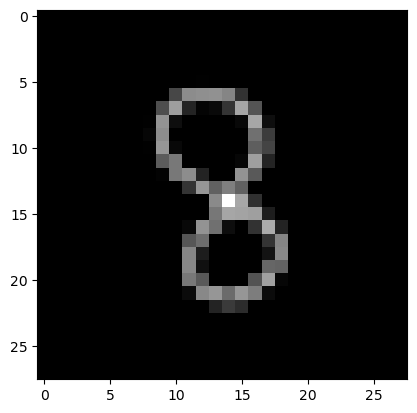

In [101]:
plt.imshow(my_image, cmap="gray")
plt.show()

In [102]:
my_image=my_image/255

In [103]:
print(f"max: {my_image.max()}")
print(f"min: {my_image.min()}")

max: 0.615686274509804
min: 0.0


In [104]:
my_image=my_image.flatten()

In [105]:
my_image.shape

(784,)

In [106]:
my_image=my_image.reshape(1, -1)

In [107]:
my_image.shape

(1, 784)

In [108]:
my_image=np.clip(my_image*6, 0, 1)

In [109]:
my_im_prediction=RF_model.predict(my_image)

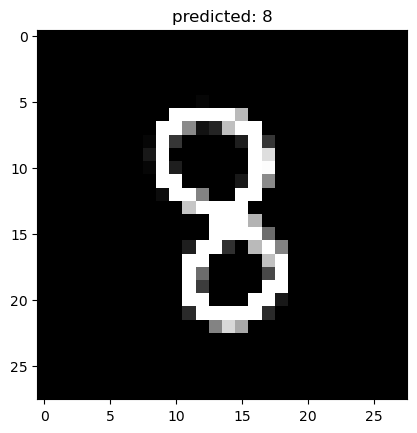

In [110]:
plt.imshow(my_image.reshape(28, 28), cmap="gray")
plt.title(f"predicted: {my_im_prediction[0]}")
plt.show()

In [111]:
np.where(y_test=="8")

(array([   36,    38,    47, ..., 13975, 13979, 13993]),)

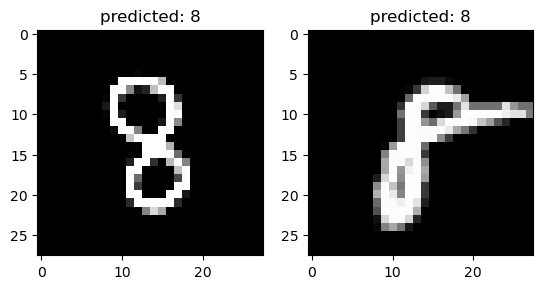

In [112]:
plt.subplot(1, 2, 1)
plt.imshow(my_image.reshape(28, 28), cmap="gray")
plt.title(f"predicted: {my_im_prediction[0]}")
plt.subplot(1, 2, 2)
plt.imshow(x_test[36].reshape(28, 28), cmap="gray")
plt.title(f"predicted: {y_test[38]}")
plt.show()

In [113]:
RF_model.predict_proba(my_image)

array([[0.  , 0.02, 0.1 , 0.15, 0.1 , 0.12, 0.01, 0.08, 0.29, 0.13]])

testing the model on my own handwritten digit:
my image was diffrent from MNIST images so I processed it before making a prediction
- converted my image to grayscale
- resized it to 28x28 pixels
- inverted it to mach the MNIST format
- normalized pixel values
- flattend it to 784 features
- adjusted the size and increasing brightness to make it similer to train data

prediction: at first the model coudent predict it correct but after few processing to make my image similer to train data the model predicted it correct